In [ ]:
import yfinance as yf

In [ ]:
acao = input("Digite o código da ação (ex: AAPL, MSFT): ")

ticker = yf.Ticker(acao)

hist = ticker.history(start='2020-01-01', end='2020-12-30')

print(hist)

Infome a ação: goog


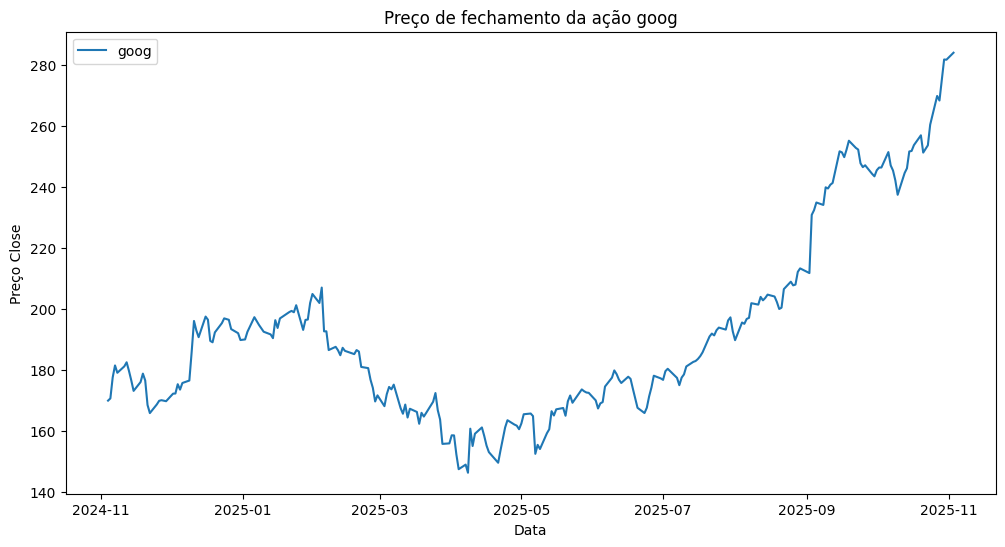

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


symbol = input('Infome a ação: ')

ticket = yf.Ticker(symbol)

historico = ticket.history(period = '1y')


df = pd.DataFrame(historico['Close'])

df.reset_index(inplace=True)

plt.figure(figsize=(12,6))

sns.lineplot(x='Date', y='Close', data = df, label = symbol)

plt.xlabel('Data')

plt.ylabel('Preço Close')
plt.title(f'Preço de fechamento da ação {symbol}')

plt.legend()
plt.show()



                                 amzn       googl        msft
Date                                                         
2024-11-04 00:00:00-05:00  195.779999  168.496933  405.416321
2024-11-05 00:00:00-05:00  199.500000  168.994736  408.393951
2024-11-06 00:00:00-05:00  207.089996  175.735001  417.048981
2024-11-07 00:00:00-05:00  210.050003  179.956375  422.259857
2024-11-08 00:00:00-05:00  208.179993  177.566925  419.391388


<Figure size 2000x1000 with 0 Axes>

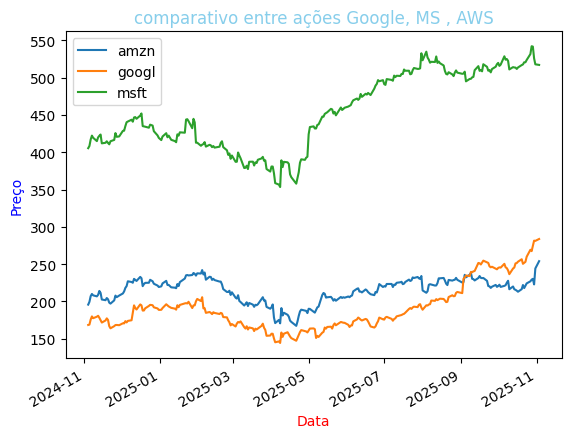

In [ ]:
symbols = ['amzn','googl','msft']

def get_history(symbol):
    ticker = yf.Ticker(symbol)
    data = ticker.history(period = '1y')['Close']
    return pd.DataFrame({symbol: data})

data_frames = [get_history(symbol) for symbol in symbols]
df = pd.concat(data_frames, axis=1)

print(df.head())

plt.figure(figsize=(20,10))

df.plot()
plt.title('comparativo entre ações Google, MS , AWS', color = 'skyblue')
plt.xlabel('Data',color='red')
plt.ylabel('Preço', color = 'blue')
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Definindo os tickers
tickers = ['MSFT', 'GOOGL']

# Baixando os dados ajustados
data = yf.download(tickers, start='2023-01-01', end='2024-01-01')['Adj Close']

# Calculando retornos
daily_returns = data.pct_change()
cumulative_returns = (1 + daily_returns).cumprod()
mean_daily_returns = daily_returns.mean()
std_daily_returns = daily_returns.std()

# Exibindo resultados
print("Retorno Diário:")
print(daily_returns.tail())

print("\nRetorno Cumulativo:")
print(cumulative_returns.tail())

print("\nRetorno Médio Diário:")
print(mean_daily_returns)

print("\nDesvio Padrão dos Retornos Diários:")
print(std_daily_returns)

# Plotando os retornos cumulativos
plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns.index, cumulative_returns['MSFT'], label='MSFT', color='b')
plt.plot(cumulative_returns.index, cumulative_returns['GOOGL'], label='GOOGL', color='g')
plt.title('Cumulative Returns of MSFT and GOOGL')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)
plt.show()
